# Custom derivative rules

Runnable locally on CPU or on a Cloud TPU VM.

- Implement actual custom_jvp and custom_vjp rules with correct return and residual contracts.
- Verify seed linearity, stable extreme values and second derivatives.
- Detect a wrong but linear derivative rule using independent numerical checks.
- Explain the forward-mode limitation of a custom_vjp function.

Sometimes you know a stable formula for a derivative, or need to control what a reverse pass saves. How do you replace JAX’s default differentiation without quietly changing the mathematics? We will write two exact custom rules, check higher derivatives, and catch a deliberately plausible wrong rule.

## The idea

A custom derivative rule changes how differentiation treats a function. It must preserve the intended derivative while respecting transformation requirements. Stability of the primal computation and correctness of the derivative need separate checks.

## A custom rule is a mathematical contract

Start from a known analytic function and derive its slope. Compare the custom rule with that result over ordinary and extreme inputs, then examine the second derivative if higher-order use is intended.

A forward rule must be linear in its tangent input; a reverse rule must be linear in its incoming cotangent. Inserting an arbitrary nonlinear operation on that sensitivity can produce a rule that no longer represents a derivative.

The slope and curvature curves show more than a successful first gradient at one point. Follow their behavior near numerically difficult regions and use finite differences only where that independent approximation is reliable.

### Pause and reason

Why check more than one tangent magnitude or cotangent value?

<details><summary>Compare your reasoning</summary>

It can expose a rule that is incorrectly nonlinear in the sensitivity input. Matching a single derivative call can hide that contract violation.

</details>

## Keep the primal stable before customizing its derivative

Softplus is $s(x)=\log(1+e^x)$. Direct exponentiation overflows for a large positive input, even though the correct output is approximately $x$. logaddexp computes the same mathematical function without forming the dangerous exponential. Its derivative is the sigmoid $\sigma(x)$, and its second derivative is $\sigma(x)(1-\sigma(x))$. We use these identities as checks, not as permission to ignore the primal calculation.

$$
s(x)=\log(1+e^x),\qquad s\prime(x)=\sigma(x),\qquad s\prime\prime(x)=\sigma(x)(1-\sigma(x))
$$

## A custom JVP must remain linear in its tangent

The JVP receives tuples of primal arguments and tangent arguments. For one scalar input, it returns $(s(x),\sigma(x)\dot{x})$. The coefficient depends on the primal point; the expression is linear in the tangent $\dot{x}$. Squaring the tangent would not represent a derivative and would prevent a valid linear transpose. Multiplying by an incorrect constant remains linear but is still mathematically wrong, so linearity checks alone cannot establish correctness.

## Choose residuals for a custom reverse pass

For $\ell(x)=\log\sum_i e^{x_i}$, the gradient is softmax $p$. The forward rule returns the scalar primal and saves $p$ as the residual. The backward rule receives that residual and a scalar output cotangent $g$, then returns the input cotangent $gp$ inside a one-element tuple. Saving probabilities is a deliberate memory/recomputation choice in this small example; it is not a universal optimal residual policy.

$$
\frac{\partial\ell}{\partial x_i}=p_i,\qquad p_i=\frac{e^{x_i}}{\sum_j e^{x_j}}
$$

## Higher-order behavior is part of the promise

Differentiating the softplus rule again should give curvature $0.25$ at zero. Differentiating the log-sum-exp reverse gradient gives $\operatorname{diag}(p)-pp^\mathsf{T}$, a symmetric Hessian whose rows sum to zero because adding a common constant changes the value linearly. The reference checks use these formulas. A stop_gradient inserted into a residual path might preserve first derivatives while breaking these higher-order checks.

## Custom reverse mode has a transformation boundary

Applying jvp directly to a custom_vjp function is unsupported in the tested JAX API. We reproduce that boundary and report it explicitly. Reverse-over-reverse differentiation of this smooth, correctly implemented rule works and is checked. If forward-mode composition is needed, use an appropriate custom_jvp or ordinary JAX implementation rather than assuming every derivative decorator is interchangeable.

## An intentionally different gradient needs a different claim

A straight-through or surrogate rule can be useful in a modeling method, but it is not the exact derivative of the reported primal. This lesson teaches exact custom derivatives. We deliberately halve a correct derivative to show that a smooth-looking result and seed linearity do not make it true. A finite-difference comparison away from flat or saturated regions exposes the error.

## Write stable primal functions and exact derivative contracts

Create main.py for the first block, then append subsequent blocks in order using your course CPU environment.

In [1]:
# Step 1 — Write stable primal functions and exact derivative contracts: The JVP rule returns primal and tangent; the VJP forward rule...
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_enable_x64", True)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np

# Register custom derivative rule on `stable_softplus(x)`:
@jax.custom_jvp
# Function `stable_softplus(x)` implementing this stage's computation:
def stable_softplus(x):
    # Return `jnp.logaddexp(0.0, x)` to the caller.
    return jnp.logaddexp(0.0,x)

@stable_softplus.defjvp
# Function `softplus_jvp(primals, tangents)` implementing this stage's computation:
def softplus_jvp(primals,tangents):
    # Evaluate `(x,)` from the current inputs and state.
    x,=primals
    # Evaluate `(dx,)` from the current inputs and state.
    dx,=tangents
    # Return `(stable_softplus(x), jax.nn.sigmoid(x) * dx)` to the caller.
    return stable_softplus(x),jax.nn.sigmoid(x)*dx

# Register custom derivative rule on `stable_logsumexp(x)`:
@jax.custom_vjp
# Function `stable_logsumexp(x)` implementing this stage's computation:
def stable_logsumexp(x):
    # Return `jax.scipy.special.logsumexp(x)` to the caller.
    return jax.scipy.special.logsumexp(x)

# Function `logsumexp_fwd(x)` implementing this stage's computation:
def logsumexp_fwd(x):
    # Evaluate numerically stable log-space cross-entropy/likelihood (`value`).
    value=stable_logsumexp(x)
    # Apply nonlinear activation or probability normalization to compute `weights`.
    weights=jax.nn.softmax(x)
    # Return `(value, weights)` to the caller.
    return value,weights

# Function `logsumexp_bwd(weights, cotangent)` implementing this stage's computation:
def logsumexp_bwd(weights,cotangent):
    # Return `(cotangent * weights,)` to the caller.
    return (cotangent*weights,)

# Evaluate numerically stable log-space cross-entropy/likelihood (``).
stable_logsumexp.defvjp(logsumexp_fwd,logsumexp_bwd)

The JVP rule returns primal and tangent; the VJP forward rule returns primal and residual, and its backward rule returns one cotangent per original input. Both preserve linearity in the directional seed.

## Check first and second derivatives independently

Create main.py for the first block, then append subsequent blocks in order using your course CPU environment.

In [2]:
# Step 2 — Check first and second derivatives independently: An exact first derivative can still hide mistakes in a...
# Initialize array `points` with explicit values and shape.
points=jnp.array([-4.,0.,3.])
# Vectorize across the batch dimension with `jax.vmap` (`values`).
values=jax.vmap(stable_softplus)(points)
# Differentiate the objective to obtain `first` via automatic differentiation.
first=jax.vmap(jax.grad(stable_softplus))(points)
# Differentiate the objective to obtain `second` via automatic differentiation.
second=jax.vmap(jax.grad(jax.grad(stable_softplus)))(points)
# Convert `reference_first` to a host NumPy array for inspection or verification.
reference_first=1/(1+np.exp(-np.asarray(points)))
# Evaluate `reference_second` from the current inputs and state.
reference_second=reference_first*(1-reference_first)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(values,np.logaddexp(0,np.asarray(points)),rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(first,reference_first,rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(second,reference_second,rtol=1e-12)
# Initialize array `x` with explicit values and shape.
x=jnp.array([-0.8,0.4,1.1])
# Convert `weights` to a host NumPy array for inspection or verification.
# Accumulate the next contribution into `weights`.
weights=np.exp(np.asarray(x)-np.max(np.asarray(x)));weights/=weights.sum()
# Run `np.diag` to compute `hessian_reference`.
hessian_reference=np.diag(weights)-np.outer(weights,weights)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(stable_logsumexp)(x),weights,rtol=1e-12)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.jacrev(jax.grad(stable_logsumexp))(x),hessian_reference,rtol=1e-12,atol=1e-12)
# Print diagnostic summary of the computed outputs.
print("Softplus first/second:",np.asarray(first),np.asarray(second))
# Print diagnostic summary of the computed outputs.
print("Logsumexp gradient:",weights)

Softplus first/second: [0.01798621 0.5        0.95257413] [0.01766271 0.25       0.04517666]
Logsumexp gradient: [0.09085944 0.30166396 0.60747661]


An exact first derivative can still hide mistakes in a higher-order rule. The softplus curvature and logsumexp Hessian are independently derived here.

## Exercise extremes and seed linearity

Create main.py for the first block, then append subsequent blocks in order using your course CPU environment.

In [3]:
# Step 3 — Exercise extremes and seed linearity: Numerical stability must hold in both the primal and derivative path.
# Initialize array `extremes` with explicit values and shape.
extremes=jnp.array([-1000.,0.,1000.])
# Vectorize across the batch dimension with `jax.vmap` (`extreme_values`).
extreme_values=jax.vmap(stable_softplus)(extremes)
# Differentiate the objective to obtain `extreme_gradients` via automatic differentiation.
extreme_gradients=jax.vmap(jax.grad(stable_softplus))(extremes)
# Confirm that all computed values remain finite (no NaN or Inf).
assert np.isfinite(extreme_values).all() and np.isfinite(extreme_gradients).all()
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(extreme_values,[0.,np.log(2.),1000.],atol=1e-12)
# Enter `np.errstate(over='ignore')` context block:
with np.errstate(over='ignore'):
    # Convert `naive` to a host NumPy array for inspection or verification.
    naive=np.log1p(np.exp(np.asarray(extremes)))
# Confirm that all computed values remain finite (no NaN or Inf).
assert not np.isfinite(naive[-1])
# Compute exact directional derivative / Jacobian / Hessian (`(_, pullback)`).
_,pullback=jax.vjp(stable_logsumexp,x)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(pullback(2.0-0.3)[0],2*pullback(1.0)[0]-pullback(0.3)[0],rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Stable extreme values:",np.asarray(extreme_values),"naive positive extreme:",naive[-1])

Stable extreme values: [0.00000000e+00 6.93147181e-01 1.00000000e+03] naive positive extreme: inf


Numerical stability must hold in both the primal and derivative path. Backward seed linearity is a contract of a true pullback, not an optional aesthetic property.

## Run the example

In [4]:
# Step 1 — Write stable primal functions and exact derivative contracts: The JVP rule returns primal and tangent; the VJP forward rule...
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_enable_x64", True)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np

# Register custom derivative rule on `stable_softplus(x)`:
@jax.custom_jvp
# Function `stable_softplus(x)` implementing this stage's computation:
def stable_softplus(x):
    # Return `jnp.logaddexp(0.0, x)` to the caller.
    return jnp.logaddexp(0.0,x)

@stable_softplus.defjvp
# Function `softplus_jvp(primals, tangents)` implementing this stage's computation:
def softplus_jvp(primals,tangents):
    # Evaluate `(x,)` from the current inputs and state.
    x,=primals
    # Evaluate `(dx,)` from the current inputs and state.
    dx,=tangents
    # Return `(stable_softplus(x), jax.nn.sigmoid(x) * dx)` to the caller.
    return stable_softplus(x),jax.nn.sigmoid(x)*dx

# Register custom derivative rule on `stable_logsumexp(x)`:
@jax.custom_vjp
# Function `stable_logsumexp(x)` implementing this stage's computation:
def stable_logsumexp(x):
    # Return `jax.scipy.special.logsumexp(x)` to the caller.
    return jax.scipy.special.logsumexp(x)

# Function `logsumexp_fwd(x)` implementing this stage's computation:
def logsumexp_fwd(x):
    # Evaluate numerically stable log-space cross-entropy/likelihood (`value`).
    value=stable_logsumexp(x)
    # Apply nonlinear activation or probability normalization to compute `weights`.
    weights=jax.nn.softmax(x)
    # Return `(value, weights)` to the caller.
    return value,weights

# Function `logsumexp_bwd(weights, cotangent)` implementing this stage's computation:
def logsumexp_bwd(weights,cotangent):
    # Return `(cotangent * weights,)` to the caller.
    return (cotangent*weights,)

# Evaluate numerically stable log-space cross-entropy/likelihood (``).
stable_logsumexp.defvjp(logsumexp_fwd,logsumexp_bwd)

# Step 2 — Check first and second derivatives independently: An exact first derivative can still hide mistakes in a...
# Initialize array `points` with explicit values and shape.
points=jnp.array([-4.,0.,3.])
# Vectorize across the batch dimension with `jax.vmap` (`values`).
values=jax.vmap(stable_softplus)(points)
# Differentiate the objective to obtain `first` via automatic differentiation.
first=jax.vmap(jax.grad(stable_softplus))(points)
# Differentiate the objective to obtain `second` via automatic differentiation.
second=jax.vmap(jax.grad(jax.grad(stable_softplus)))(points)
# Convert `reference_first` to a host NumPy array for inspection or verification.
reference_first=1/(1+np.exp(-np.asarray(points)))
# Evaluate `reference_second` from the current inputs and state.
reference_second=reference_first*(1-reference_first)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(values,np.logaddexp(0,np.asarray(points)),rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(first,reference_first,rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(second,reference_second,rtol=1e-12)
# Initialize array `x` with explicit values and shape.
x=jnp.array([-0.8,0.4,1.1])
# Convert `weights` to a host NumPy array for inspection or verification.
# Accumulate the next contribution into `weights`.
weights=np.exp(np.asarray(x)-np.max(np.asarray(x)));weights/=weights.sum()
# Run `np.diag` to compute `hessian_reference`.
hessian_reference=np.diag(weights)-np.outer(weights,weights)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(stable_logsumexp)(x),weights,rtol=1e-12)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.jacrev(jax.grad(stable_logsumexp))(x),hessian_reference,rtol=1e-12,atol=1e-12)
# Print diagnostic summary of the computed outputs.
print("Softplus first/second:",np.asarray(first),np.asarray(second))
# Print diagnostic summary of the computed outputs.
print("Logsumexp gradient:",weights)

# Step 3 — Exercise extremes and seed linearity: Numerical stability must hold in both the primal and derivative path.
# Initialize array `extremes` with explicit values and shape.
extremes=jnp.array([-1000.,0.,1000.])
# Vectorize across the batch dimension with `jax.vmap` (`extreme_values`).
extreme_values=jax.vmap(stable_softplus)(extremes)
# Differentiate the objective to obtain `extreme_gradients` via automatic differentiation.
extreme_gradients=jax.vmap(jax.grad(stable_softplus))(extremes)
# Confirm that all computed values remain finite (no NaN or Inf).
assert np.isfinite(extreme_values).all() and np.isfinite(extreme_gradients).all()
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(extreme_values,[0.,np.log(2.),1000.],atol=1e-12)
# Enter `np.errstate(over='ignore')` context block:
with np.errstate(over='ignore'):
    # Convert `naive` to a host NumPy array for inspection or verification.
    naive=np.log1p(np.exp(np.asarray(extremes)))
# Confirm that all computed values remain finite (no NaN or Inf).
assert not np.isfinite(naive[-1])
# Compute exact directional derivative / Jacobian / Hessian (`(_, pullback)`).
_,pullback=jax.vjp(stable_logsumexp,x)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(pullback(2.0-0.3)[0],2*pullback(1.0)[0]-pullback(0.3)[0],rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Stable extreme values:",np.asarray(extreme_values),"naive positive extreme:",naive[-1])

Softplus first/second: [0.01798621 0.5        0.95257413] [0.01766271 0.25       0.04517666]
Logsumexp gradient: [0.09085944 0.30166396 0.60747661]
Stable extreme values: [0.00000000e+00 6.93147181e-01 1.00000000e+03] naive positive extreme: inf


Expected: Softplus derivatives at zero are 0.5 and 0.25. Stable values at [-1000, 0, 1000] are [0, log(2), 1000]; the naive positive extreme overflows. The custom reverse Hessian matches diag(p)-p p-transpose.

## A stable custom rule preserves both slope and curvature

Predict: Where should softplus have the greatest curvature, and what happens far into either tail?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: A stable custom rule preserves both slope and curvature
# Generate a uniform grid of points in `grid`.
grid=jnp.linspace(-8.,8.,65)
# Convert `slopes` to a host NumPy array for inspection or verification.
slopes=np.asarray(jax.vmap(jax.grad(stable_softplus))(grid))
# Convert `curvatures` to a host NumPy array for inspection or verification.
curvatures=np.asarray(jax.vmap(jax.grad(jax.grad(stable_softplus)))(grid))
# Convert `visual_data` to a host NumPy array for inspection or verification.
visual_data={'panels':[{'kind':'line','x':np.asarray(grid).tolist(),'xlabel':'input x','ylabel':'first derivative','series':[{'label':'custom softplus slope','y':slopes.tolist()}]},{'kind':'line','x':np.asarray(grid).tolist(),'xlabel':'input x','ylabel':'second derivative','series':[{'label':'custom softplus curvature','y':curvatures.tolist()}]}]}

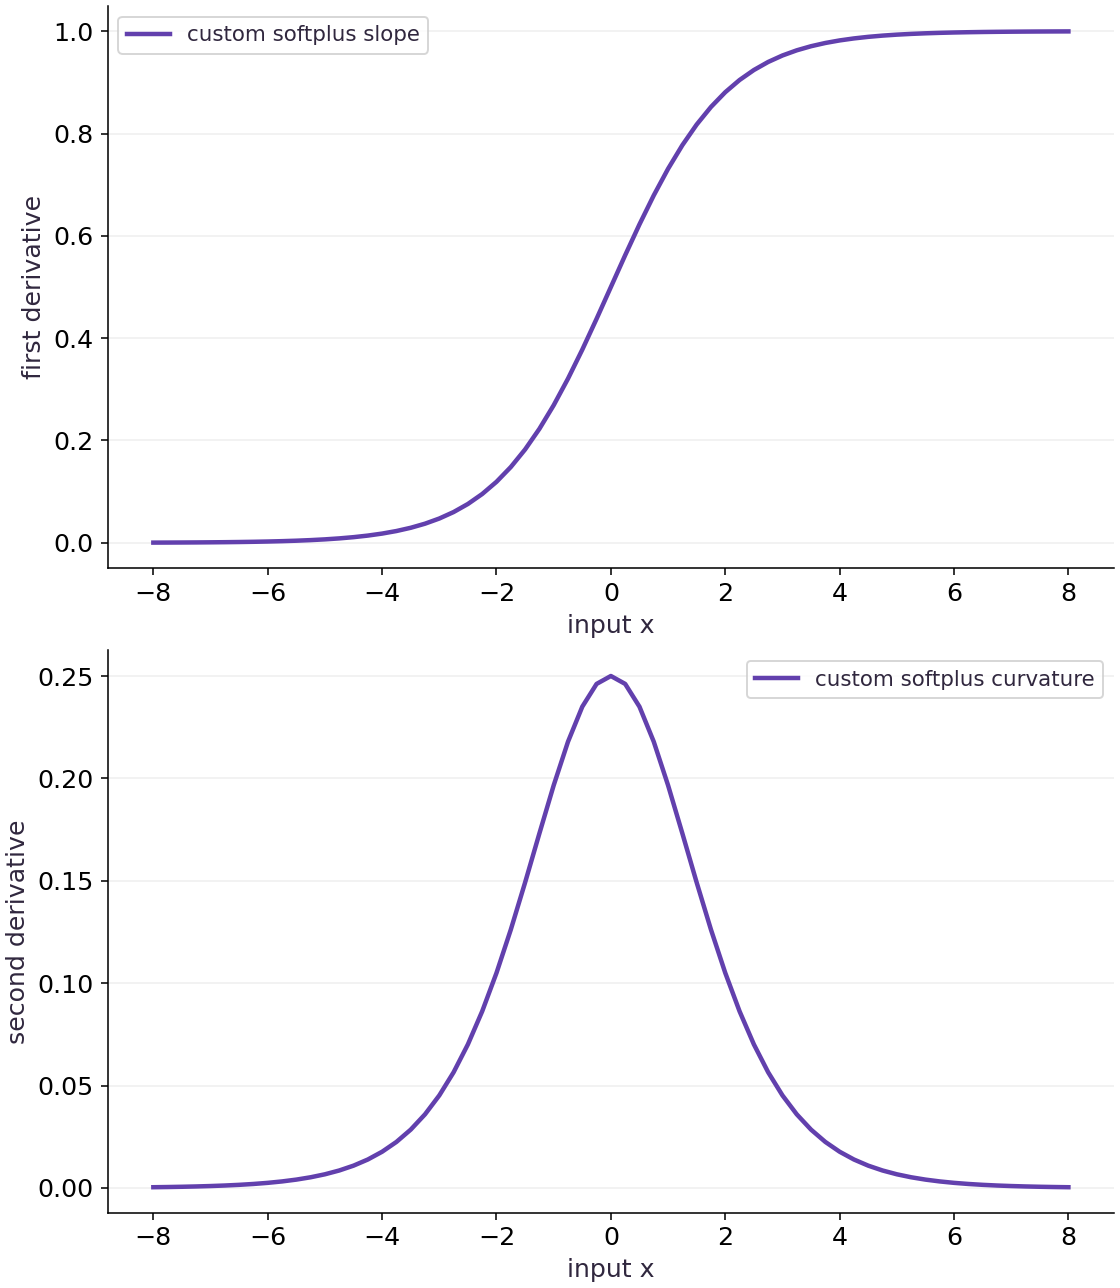

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The upper panel plots the first derivative of the custom softplus against its scalar input. It rises smoothly from near zero to near one and passes through $0.5$ at zero. This is sensitivity, not the softplus value itself.

The lower panel plots the second derivative on the same input range. It reaches $0.25$ at zero and falls to about $0.01766$ at both $-4$ and $4$. The curvature is symmetric even though the first derivative is not.

### Connect it to the computation

The plotted values come from differentiating the registered custom rule, including differentiating it twice. Independent sigmoid and sigmoid-times-one-minus-sigmoid formulas check the numerical values at named points. The high-curvature central region is useful for detecting a wrong coefficient.

The separate extreme-input test reaches magnitude one thousand, beyond this display, to check overflow behavior. A smooth curve here cannot establish correctness in every transform or dtype; the VJP interface-boundary experiment and changed-size practice test other parts of the contract.

## Expose a wrong but linear rule

Predict: Would halving the derivative violate seed linearity? Would it still be the derivative of softplus?

In [7]:
# Experiment — Expose a wrong but linear rule: The wrong tangent expression is linear, so transposition can...
# Register custom derivative rule on `wrong_softplus(z)`:
@jax.custom_jvp
# Function `wrong_softplus(z)` implementing this stage's computation:
def wrong_softplus(z):
    # Return `jnp.logaddexp(0.0, z)` to the caller.
    return jnp.logaddexp(0.0,z)
@wrong_softplus.defjvp
# Function `wrong_rule(primals, tangents)` implementing this stage's computation:
def wrong_rule(primals,tangents):
    # Evaluate `(z,)` from the current inputs and state.
    # Evaluate `(dz,)` from the current inputs and state.
    z,=primals;dz,=tangents
    # Return `(wrong_softplus(z), 0.5 * jax.nn.sigmoid(z) * dz)` to the caller.
    return wrong_softplus(z),0.5*jax.nn.sigmoid(z)*dz
# Evaluate `probe` from the current inputs and state.
# Evaluate `eps` from the current inputs and state.
probe=0.4;eps=1e-5
# Evaluate `finite` from the current inputs and state.
finite=(np.logaddexp(0,probe+eps)-np.logaddexp(0,probe-eps))/(2*eps)
# Differentiate the objective to obtain `wrong` via automatic differentiation.
wrong=float(jax.grad(wrong_softplus)(probe))
# Differentiate the objective to obtain `right` via automatic differentiation.
right=float(jax.grad(stable_softplus)(probe))
# Verify contract: `abs(wrong - finite) > 0.2`.
assert abs(wrong-finite)>0.2
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(right,finite,rtol=1e-9)
# Print the observed values to compare against the expected result.
print("Wrong/correct/finite-difference derivative:",wrong,right,finite)

Wrong/correct/finite-difference derivative: 0.29934383005622606 0.5986876601124521 0.5986876601138391


Expected: Wrong derivative approximately 0.29934; correct and finite-difference derivatives approximately 0.59869.

The wrong tangent expression is linear, so transposition can still work. Only an independent mathematical or numerical oracle detects its incorrect coefficient.

## Exercise the custom VJP boundary

Predict: Can a custom reverse rule automatically supply a direct forward-mode product?

In [8]:
# Experiment — Exercise the custom VJP boundary: Adding the same constant to all logits shifts log-sum-exp by...
rejected=False
# Run the boundary check and catch the expected exception:
try:
    jax.jvp(stable_logsumexp,(x,),(jnp.ones_like(x),))
except TypeError as error:
    rejected=True
    print("Expected custom_vjp forward-mode boundary:",str(error).splitlines()[0])
# Verify contract: `rejected`.
assert rejected
# Evaluate numerically stable log-space cross-entropy/likelihood (`ordinary`).
ordinary=lambda z:jax.scipy.special.logsumexp(z)
# Compute exact directional derivative / Jacobian / Hessian (`ordinary_direction`).
ordinary_direction=jax.jvp(ordinary,(x,),(jnp.ones_like(x),))[1]
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(ordinary_direction,1.0,atol=1e-12)
# Print the observed values to compare against the expected result.
print("Ordinary JAX common-shift JVP:",float(ordinary_direction))

Expected custom_vjp forward-mode boundary: can't apply forward-mode autodiff (jvp) to a custom_vjp function.
Ordinary JAX common-shift JVP: 1.0


Expected: The custom_vjp direct JVP is rejected; the ordinary function gives directional derivative 1.

Adding the same constant to all logits shifts log-sum-exp by that constant. The mathematical derivative exists; the limitation belongs to the custom_vjp transformation interface.

## Your exercise

Check the custom log-sum-exp gradient on $(-3,0.2,2,5)$ against an independent stable softmax and central differences along two directions. Keep the output cotangent explicit.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Initialize array `changed` with explicit values and shape.
2. Convert `host` to a host NumPy array for inspection or verification.
3. Reduce across the target axis to summarize `p`.
4. Accumulate the next contribution into `p`.
5. Differentiate the objective to obtain `actual` via automatic differentiation.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Check the custom log-sum-exp gradient on (-3,0.2,2,5) against an...
# Initialize array `changed` with explicit values and shape.
changed = jnp.array(...)  # TODO: compute changed
# Convert `host` to a host NumPy array for inspection or verification.
# Reduce across the target axis to summarize `p`.
# Accumulate the next contribution into `p`.
host = np.asarray(...)  # TODO: compute host
# Differentiate the objective to obtain `actual` via automatic differentiation.
actual = jax.grad(...)  # TODO: compute actual
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(actual,p,rtol = ...  # TODO: compute np.testing.assert_allclose(actual,p,rtol
# Iterate over `direction` to step through the computation:
for direction in (np.array([1.,-.5,.2,0.]),np.array([0.,1.,-1.,.3])):
    # Evaluate `eps` from the current inputs and state.
    eps = ...  # TODO: compute eps
    # Aggregate array values to compute `reference`.
    reference = ...  # TODO: compute reference
    # Evaluate `fd` from the current inputs and state.
    fd = ...  # TODO: compute fd
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.dot(np.asarray(actual),direction),fd,rtol = ...  # TODO: compute np.testing.assert_allclose(np.dot(np.asarray(actual),direction),fd,rtol
# Evaluate primal output and reverse-mode pullback function (``).
np.testing.assert_allclose(jax.vjp(stable_logsumexp,changed)[1](2.5)[0],2.5*p,rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Changed-size gradient and cotangent scaling verified")
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Check the custom log-sum-exp gradient on (-3,0.2,2,5) against an...
# Initialize array `changed` with explicit values and shape.
# changed = jnp.array(...)  # TODO: compute changed
# Convert `host` to a host NumPy array for inspection or verification.
# Reduce across the target axis to summarize `p`.
# Accumulate the next contribution into `p`.
# host = np.asarray(...)  # TODO: compute host
# Differentiate the objective to obtain `actual` via automatic differentiation.
# actual = jax.grad(...)  # TODO: compute actual
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(actual,p,rtol = ...  # TODO: compute np.testing.assert_allclose(actual,p,rtol
# Iterate over `direction` to step through the computation:
# for direction in (np.array([1.,-.5,.2,0.]),np.array([0.,1.,-1.,.3])):
    # Evaluate `eps` from the current inputs and state.
#     eps = ...  # TODO: compute eps
    # Aggregate array values to compute `reference`.
#     reference = ...  # TODO: compute reference
    # Evaluate `fd` from the current inputs and state.
#     fd = ...  # TODO: compute fd
    # Convert `` to a host NumPy array for inspection or verification.
#     np.testing.assert_allclose(np.dot(np.asarray(actual),direction),fd,rtol = ...  # TODO: compute np.testing.assert_allclose(np.dot(np.asarray(actual),direction),fd,rtol
# Evaluate primal output and reverse-mode pullback function (``).
# np.testing.assert_allclose(jax.vjp(stable_logsumexp,changed)[1](2.5)[0],2.5*p,rtol=1e-12)
# Print the observed values to compare against the expected result.
# print("Changed-size gradient and cotangent scaling verified")

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Check the custom log-sum-exp gradient on (-3,0.2,2,5) against an...
# Initialize array `changed` with explicit values and shape.
changed=jnp.array([-3.,0.2,2.,5.])
# Convert `host` to a host NumPy array for inspection or verification.
# Reduce across the target axis to summarize `p`.
# Accumulate the next contribution into `p`.
host=np.asarray(changed);p=np.exp(host-host.max());p/=p.sum()
# Differentiate the objective to obtain `actual` via automatic differentiation.
actual=jax.grad(stable_logsumexp)(changed)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(actual,p,rtol=1e-12)
# Iterate over `direction` to step through the computation:
for direction in (np.array([1.,-.5,.2,0.]),np.array([0.,1.,-1.,.3])):
    # Evaluate `eps` from the current inputs and state.
    eps=1e-5
    # Aggregate array values to compute `reference`.
    reference=lambda z:np.max(z)+np.log(np.exp(z-np.max(z)).sum())
    # Evaluate `fd` from the current inputs and state.
    fd=(reference(host+eps*direction)-reference(host-eps*direction))/(2*eps)
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.dot(np.asarray(actual),direction),fd,rtol=1e-8,atol=1e-10)
# Evaluate primal output and reverse-mode pullback function (``).
np.testing.assert_allclose(jax.vjp(stable_logsumexp,changed)[1](2.5)[0],2.5*p,rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Changed-size gradient and cotangent scaling verified")

Changed-size gradient and cotangent scaling verified


## Check common-shift invariance of curvature · Practice

Add a common constant of $1000$ to every logit. Verify the value shift, unchanged gradient, and Hessian row sums.

Hint: Use stable references and avoid direct exponentiation of the shifted logits.

### How to write: Check common-shift invariance of curvature — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.jvp / jax.vjp / jax.jacfwd / jax.hessian` — Computes exact forward-mode JVP, reverse-mode VJP, full Jacobians, or second-order curvature.

**Step-by-step implementation plan:**
1. Evaluate numerically stable log-space cross-entropy/likelihood (``).
2. Differentiate the objective to obtain gradients ``.
3. Differentiate the objective to obtain `hess` via automatic differentiation.
4. Reduce across the target axis to summarize ``.
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Check common-shift invariance of curvature (Practice): The common shift leaves probabilities unchanged.
shift = ...  # TODO: compute shift
# Evaluate numerically stable log-space cross-entropy/likelihood (``).
np.testing.assert_allclose(stable_logsumexp(x+shift)-stable_logsumexp(x),shift,rtol=1e-12)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(stable_logsumexp)(x+shift),jax.grad(stable_logsumexp)(x),rtol=1e-12)
# Differentiate the objective to obtain `hess` via automatic differentiation.
hess = jax.jacrev(...)  # TODO: compute hess
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(jnp.sum(hess,axis = ...  # TODO: compute np.testing.assert_allclose(jnp.sum(hess,axis
# Print the observed values to compare against the expected result.
print("Stable shift invariance and zero common-direction curvature verified")
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check common-shift invariance of curvature (Practice): The common shift leaves probabilities unchanged.
# shift = ...  # TODO: compute shift
# Evaluate numerically stable log-space cross-entropy/likelihood (``).
# np.testing.assert_allclose(stable_logsumexp(x+shift)-stable_logsumexp(x),shift,rtol=1e-12)
# Differentiate the objective to obtain gradients ``.
# np.testing.assert_allclose(jax.grad(stable_logsumexp)(x+shift),jax.grad(stable_logsumexp)(x),rtol=1e-12)
# Differentiate the objective to obtain `hess` via automatic differentiation.
# hess = jax.jacrev(...)  # TODO: compute hess
# Reduce across the target axis to summarize ``.
# np.testing.assert_allclose(jnp.sum(hess,axis = ...  # TODO: compute np.testing.assert_allclose(jnp.sum(hess,axis
# Print the observed values to compare against the expected result.
# print("Stable shift invariance and zero common-direction curvature verified")

## Reference reasoning

The common shift leaves probabilities unchanged. Zero curvature in that direction is a structural identity, not a numerical accident.

In [12]:
# Check common-shift invariance of curvature (Practice): The common shift leaves probabilities unchanged.
shift=1000.0
# Evaluate numerically stable log-space cross-entropy/likelihood (``).
np.testing.assert_allclose(stable_logsumexp(x+shift)-stable_logsumexp(x),shift,rtol=1e-12)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(stable_logsumexp)(x+shift),jax.grad(stable_logsumexp)(x),rtol=1e-12)
# Differentiate the objective to obtain `hess` via automatic differentiation.
hess=jax.jacrev(jax.grad(stable_logsumexp))(x+shift)
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(jnp.sum(hess,axis=1),0.,atol=1e-12)
# Print the observed values to compare against the expected result.
print("Stable shift invariance and zero common-direction curvature verified")

Stable shift invariance and zero common-direction curvature verified


## Audit a nonlinear seed rule before registering it · Challenge

A proposed JVP returns $\sigma(x)\dot{x}^2$. Show explicitly why it cannot be the derivative map, then repair it and test a mixed linear combination.

Hint: At fixed x, compare the response to twice a tangent with twice the response.

### How to write: Audit a nonlinear seed rule before registering it — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.jvp / jax.vjp / jax.jacfwd / jax.hessian` — Computes exact forward-mode JVP, reverse-mode VJP, full Jacobians, or second-order curvature.

**Step-by-step implementation plan:**
1. Evaluate `bad` from the current inputs and state.
2. Verify that the numerical values match the expected reference within tolerance.
3. Compute exact directional derivative / Jacobian / Hessian (`good`).
4. Verify that computed values match the expected reference within numerical tolerance.
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Audit a nonlinear seed rule before registering it (Challenge): Linearity follows from the definition of a derivative at a...
coefficient = float(...)  # TODO: compute coefficient
# Evaluate `bad` from the current inputs and state.
bad = ...  # TODO: compute bad
# Verify that the numerical values match the expected reference within tolerance.
assert not np.isclose(bad(2.0),2*bad(1.0))  # TODO: complete assertion check
# Compute exact directional derivative / Jacobian / Hessian (`good`).
good = ...  # TODO: compute good
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(good(2*.7-.3),2*good(.7)-good(.3),rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Nonlinear seed rule rejected by its contract; repaired JVP is linear")
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Audit a nonlinear seed rule before registering it (Challenge): Linearity follows from the definition of a derivative at a...
# coefficient = float(...)  # TODO: compute coefficient
# Evaluate `bad` from the current inputs and state.
# bad = ...  # TODO: compute bad
# Verify that the numerical values match the expected reference within tolerance.
# assert not np.isclose(bad(2.0),2*bad(1.0))  # TODO: complete assertion check
# Compute exact directional derivative / Jacobian / Hessian (`good`).
# good = ...  # TODO: compute good
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(good(2*.7-.3),2*good(.7)-good(.3),rtol=1e-12)
# Print the observed values to compare against the expected result.
# print("Nonlinear seed rule rejected by its contract; repaired JVP is linear")

## Reference reasoning

Linearity follows from the definition of a derivative at a fixed primal point. API acceptance is not a substitute for this mathematical check.

In [14]:
# Audit a nonlinear seed rule before registering it (Challenge): Linearity follows from the definition of a derivative at a...
coefficient=float(jax.nn.sigmoid(0.4))
# Evaluate `bad` from the current inputs and state.
bad=lambda tangent:coefficient*tangent*tangent
# Verify that the numerical values match the expected reference within tolerance.
assert not np.isclose(bad(2.0),2*bad(1.0))
# Compute exact directional derivative / Jacobian / Hessian (`good`).
good=lambda tangent:jax.jvp(stable_softplus,(jnp.array(0.4),),(jnp.array(tangent),))[1]
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(good(2*.7-.3),2*good(.7)-good(.3),rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Nonlinear seed rule rejected by its contract; repaired JVP is linear")

Nonlinear seed rule rejected by its contract; repaired JVP is linear


## Checkpoint

A custom derivative is linear in its tangent and returns finite values. What additional evidence is necessary before calling it exact?

1. Agreement with the actual primal derivative through an independent derivation or numerical check.
2. A larger batch size so its bars look smoother.
3. No additional evidence: linearity guarantees the coefficient is correct.

## Diagnose

If first derivatives pass but second derivatives fail, inspect whether residuals or derivative coefficients have been detached. If extreme values are nonfinite, inspect both primal and derivative expressions. If a custom VJP direct JVP fails, treat that as an interface boundary. If a plausible custom gradient differs from finite differences, do not relabel it exact without a valid derivation.

## Evidence

Stable extreme inputs, analytic slopes/Hessians, seed linearity, independent finite differences and a deliberately wrong-rule diagnosis. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Keep the primal stable before customizing its derivative
- A custom JVP must remain linear in its tangent
- Choose residuals for a custom reverse pass
- Higher-order behavior is part of the promise
- Custom reverse mode has a transformation boundary
- An intentionally different gradient needs a different claim

## Primary references

- [JAX automatic differentiation cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)
- [Custom JVP and VJP rules](https://docs.jax.dev/en/latest/notebooks/Custom_derivative_rules_for_Python_code.html)
- [Ahead-of-time lowering and compilation](https://docs.jax.dev/en/latest/aot.html)
- [The jaxpr language](https://docs.jax.dev/en/latest/601/jaxpr.html)